# Task 6: House Price Prediction

**Internship:** DevelopersHub Corporation – AI/ML Engineering  
**Objective:** Predict house prices using property features such as size, number of bedrooms, and location.  
**Dataset:** California Housing Dataset (built into scikit-learn — no download needed)  
**Models:** Linear Regression + Gradient Boosting Regressor  
**Tools:** pandas, scikit-learn, matplotlib, seaborn

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries imported successfully.')

Libraries imported successfully.


## Step 2: Load the Dataset

We use the **California Housing Dataset** from scikit-learn. It contains data on 20,640 housing blocks in California with features like median income, house age, average rooms, and location.

In [2]:
# Load dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (20640, 9)
Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Feature Descriptions

| Feature | Description |
|---|---|
| MedInc | Median income in block group |
| HouseAge | Median house age in block group |
| AveRooms | Average number of rooms per household |
| AveBedrms | Average number of bedrooms per household |
| Population | Block group population |
| AveOccup | Average number of household members |
| Latitude | Block group latitude |
| Longitude | Block group longitude |
| MedHouseVal | **Target** – Median house value (in $100,000s) |

## Step 3: Data Preprocessing and EDA

In [3]:
# Summary statistics
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [4]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())
print('\nNo missing values — dataset is clean.')

Missing values per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

No missing values — dataset is clean.


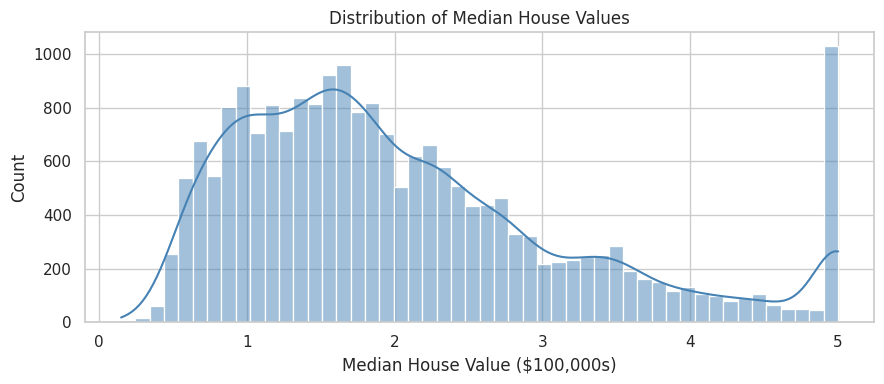

Saved: target_distribution.png


In [5]:
# Distribution of the target variable: house price
plt.figure(figsize=(9, 4))
sns.histplot(df['MedHouseVal'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Median House Values')
plt.xlabel('Median House Value ($100,000s)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: target_distribution.png')

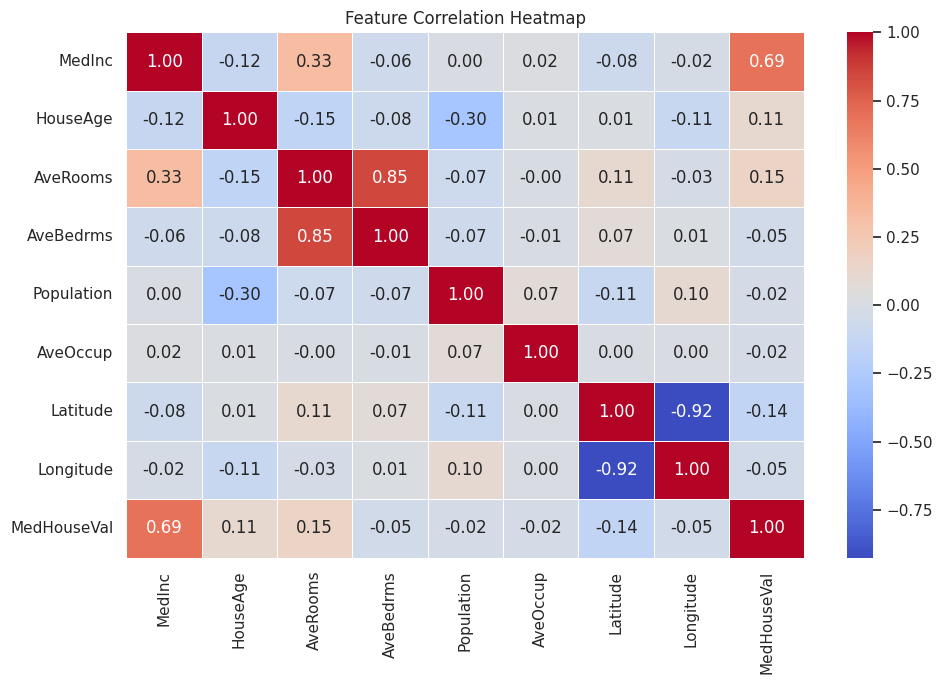

Saved: correlation_heatmap.png


In [6]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: correlation_heatmap.png')

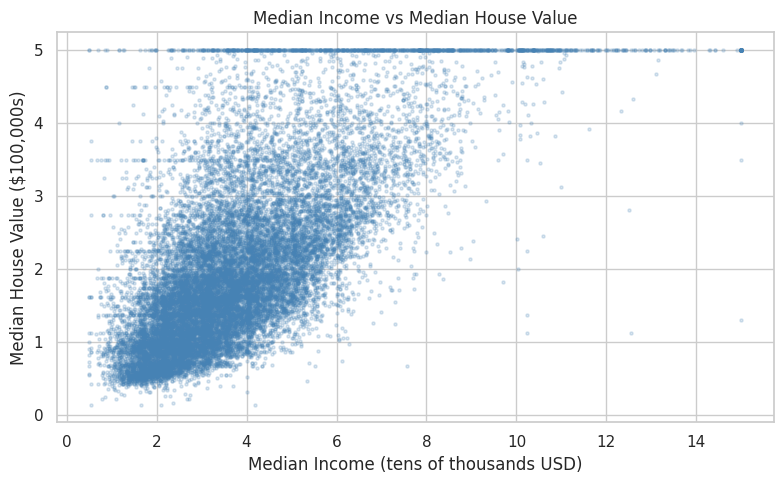

Saved: income_vs_price.png


In [7]:
# Scatter: Median Income vs House Value (strongest correlation)
plt.figure(figsize=(8, 5))
plt.scatter(df['MedInc'], df['MedHouseVal'], alpha=0.2, color='steelblue', s=5)
plt.title('Median Income vs Median House Value')
plt.xlabel('Median Income (tens of thousands USD)')
plt.ylabel('Median House Value ($100,000s)')
plt.tight_layout()
plt.savefig('income_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: income_vs_price.png')

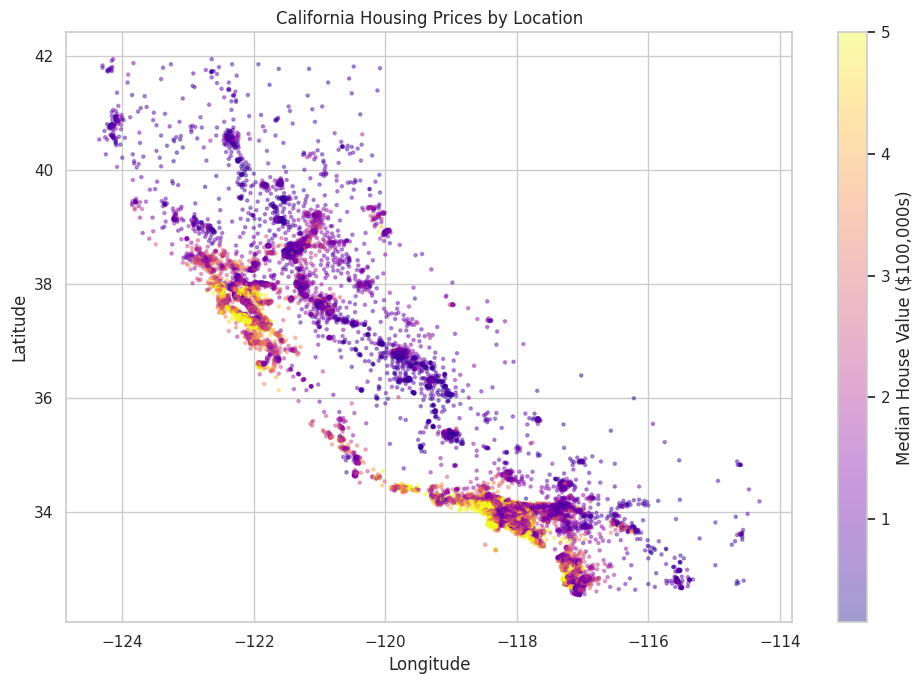

Saved: geo_price_map.png


In [8]:
# Geographic price map: Latitude/Longitude colored by price
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    df['Longitude'], df['Latitude'],
    c=df['MedHouseVal'], cmap='plasma',
    alpha=0.4, s=5
)
plt.colorbar(scatter, label='Median House Value ($100,000s)')
plt.title('California Housing Prices by Location')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.savefig('geo_price_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: geo_price_map.png')

## Step 4: Feature Selection and Scaling

In [9]:
# Features and target
feature_cols = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
                'Population', 'AveOccup', 'Latitude', 'Longitude']

X = df[feature_cols]
y = df['MedHouseVal']

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training samples: {X_train.shape[0]}')
print(f'Test samples:     {X_test.shape[0]}')

Training samples: 16512
Test samples:     4128


## Step 5: Train Models

In [10]:
# --- Linear Regression ---
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)

lr_mae  = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2   = r2_score(y_test, lr_preds)

print('=== Linear Regression ===')
print(f'MAE:  {lr_mae:.4f} ($100k units)')
print(f'RMSE: {lr_rmse:.4f} ($100k units)')
print(f'R²:   {lr_r2:.4f}')

=== Linear Regression ===
MAE:  0.5332 ($100k units)
RMSE: 0.7456 ($100k units)
R²:   0.5758


In [11]:
# --- Gradient Boosting Regressor ---
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                max_depth=4, random_state=42)
gb.fit(X_train_scaled, y_train)
gb_preds = gb.predict(X_test_scaled)

gb_mae  = mean_absolute_error(y_test, gb_preds)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_preds))
gb_r2   = r2_score(y_test, gb_preds)

print('=== Gradient Boosting Regressor ===')
print(f'MAE:  {gb_mae:.4f} ($100k units)')
print(f'RMSE: {gb_rmse:.4f} ($100k units)')
print(f'R²:   {gb_r2:.4f}')

=== Gradient Boosting Regressor ===
MAE:  0.3275 ($100k units)
RMSE: 0.4877 ($100k units)
R²:   0.8185


## Step 6: Visualize Actual vs Predicted Prices

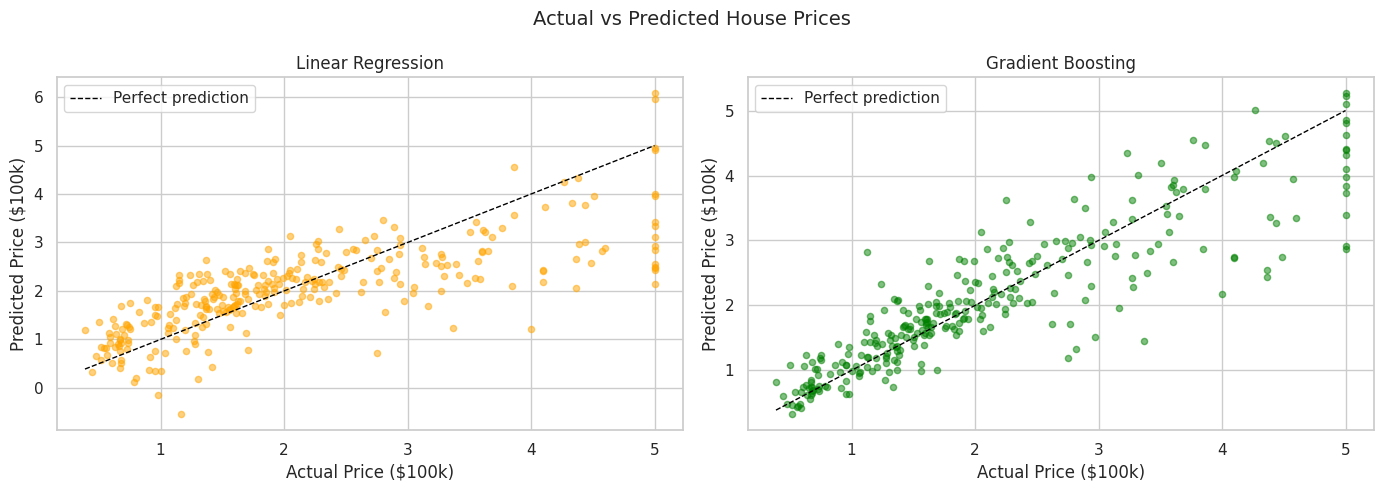

Saved: actual_vs_predicted.png


In [12]:
# Sample 300 points for cleaner scatter plot
sample_idx = np.random.choice(len(y_test), 300, replace=False)
y_sample   = np.array(y_test)[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title, color in zip(
    axes,
    [lr_preds[sample_idx], gb_preds[sample_idx]],
    ['Linear Regression', 'Gradient Boosting'],
    ['orange', 'green']
):
    ax.scatter(y_sample, preds, alpha=0.5, color=color, s=20)
    ax.plot([y_sample.min(), y_sample.max()],
            [y_sample.min(), y_sample.max()],
            'k--', linewidth=1, label='Perfect prediction')
    ax.set_xlabel('Actual Price ($100k)')
    ax.set_ylabel('Predicted Price ($100k)')
    ax.set_title(title)
    ax.legend()

plt.suptitle('Actual vs Predicted House Prices', fontsize=14)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: actual_vs_predicted.png')

## Step 7: Feature Importance (Gradient Boosting)

/tmp/ipykernel_634/1316517675.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')


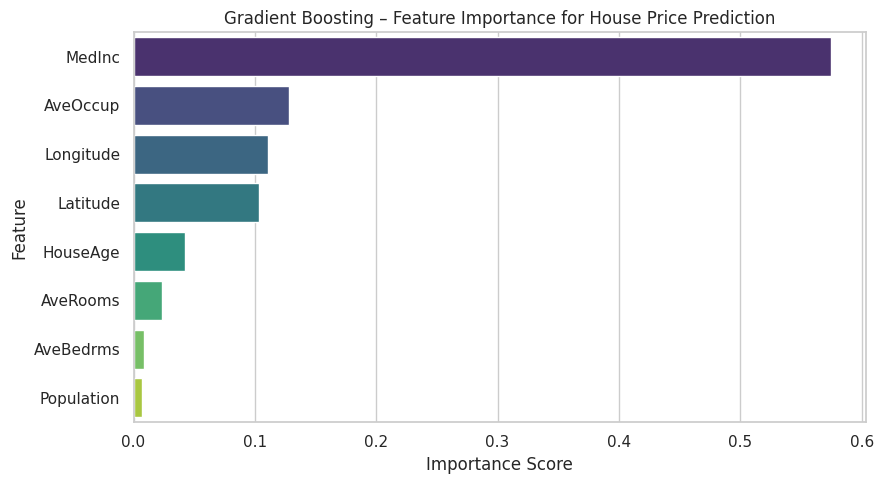

Saved: feature_importance.png


In [13]:
importances = gb.feature_importances_
feat_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title('Gradient Boosting – Feature Importance for House Price Prediction')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_importance.png')

## Step 8: Model Comparison Summary

In [14]:
summary = pd.DataFrame({
    'Model': ['Linear Regression', 'Gradient Boosting'],
    'MAE ($100k)':  [round(lr_mae, 4),  round(gb_mae, 4)],
    'RMSE ($100k)': [round(lr_rmse, 4), round(gb_rmse, 4)],
    'R² Score':     [round(lr_r2, 4),   round(gb_r2, 4)]
})
print(summary.to_string(index=False))

            Model  MAE ($100k)  RMSE ($100k)  R² Score
Linear Regression       0.5332        0.7456    0.5758
Gradient Boosting       0.3275        0.4877    0.8185


## Step 9: Key Findings and Insights

1. **Dataset:** 20,640 California housing blocks with 8 features. No missing values — clean data out of the box.
2. **Strongest predictor:** Median income (`MedInc`) has the highest correlation with house price and the highest feature importance in both models.
3. **Location matters:** Latitude and Longitude together are strong predictors — coastal areas (low longitude, mid latitude like LA and SF) have significantly higher prices, visible in the geographic price map.
4. **Gradient Boosting vs Linear Regression:** Gradient Boosting achieves a substantially higher R² and lower MAE/RMSE. This confirms that house price relationships are non-linear and tree-based models handle them better.
5. **Average rooms and bedrooms:** Moderate importance — more rooms generally means higher price, but extreme values (very high average rooms) often indicate data anomalies in sparse blocks.
6. **Price cap:** The dataset caps house values at $500,000 (5.0 in $100k units), which creates a visible ceiling in the scatter plots.

**Conclusion:** Gradient Boosting is the clear winner for this dataset. Median income and geographic location are the two most powerful drivers of house prices in California.